# Credit Risk Model - Exploratory Data Analysis

## Objective
The objective of this notebook is to explore the Xente transaction dataset, understand data quality, identify patterns, detect missing values and outliers, and generate insights that will guide feature engineering and model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display all columns
pd.set_option('display.max_columns', None)

# make plots look better
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# load transaction dataset
df = pd.read_csv("../data/raw/data.csv")

# load variable definitions
definitions = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
df.shape

(95662, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [6]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [8]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [9]:
# Show missing values as percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


In [10]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [12]:
# Select categorical columns
categorical_columns = df.select_dtypes(include="str").columns

categorical_columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

In [13]:
# Count unique values in each categorical column
df[categorical_columns].nunique().sort_values(ascending=False)

TransactionId           95662
BatchId                 94809
TransactionStartTime    94556
CustomerId               3742
AccountId                3633
SubscriptionId           3627
ProductId                  23
ProductCategory             9
ProviderId                  6
ChannelId                   4
CurrencyCode                1
dtype: int64

In [14]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

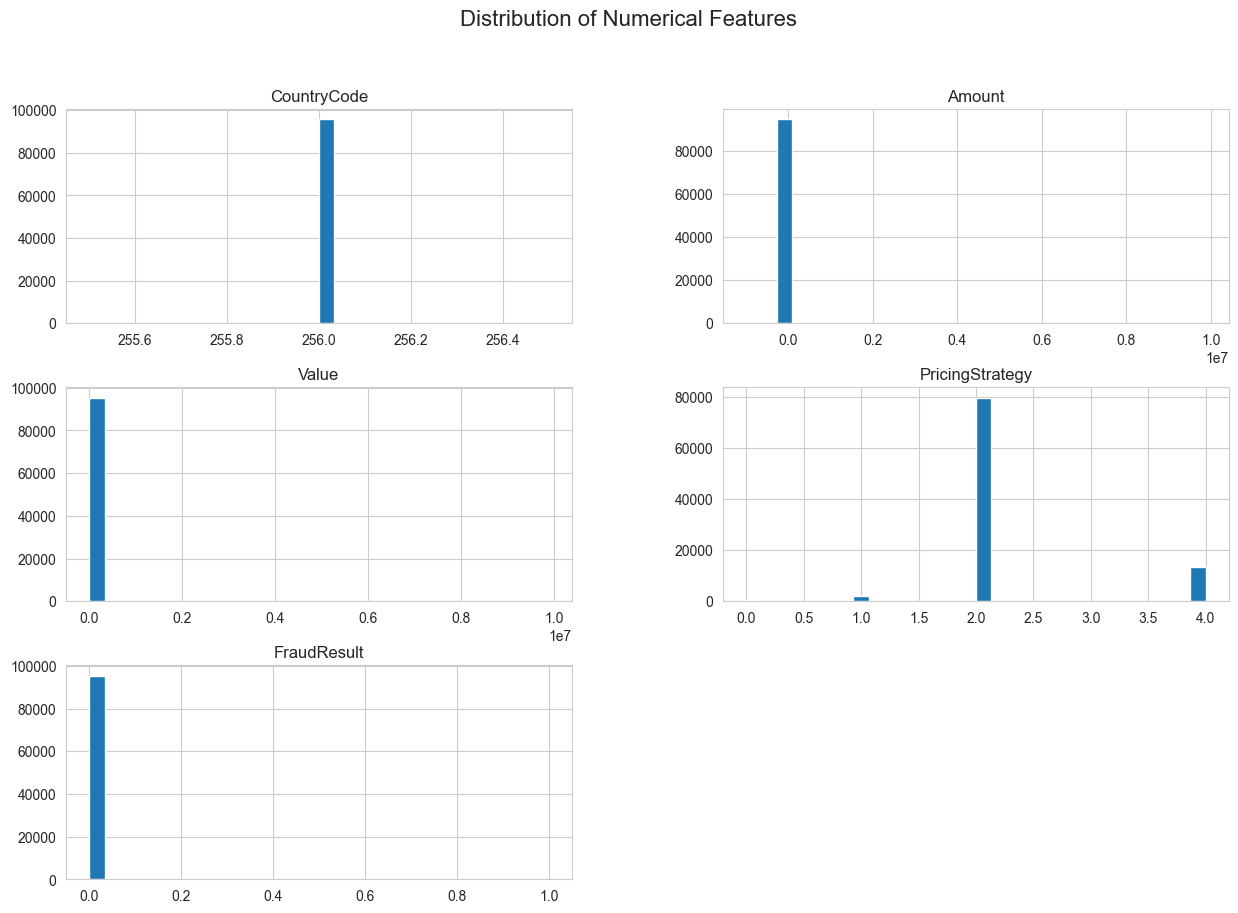

In [15]:
# Plot histograms for numerical features

df[numerical_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

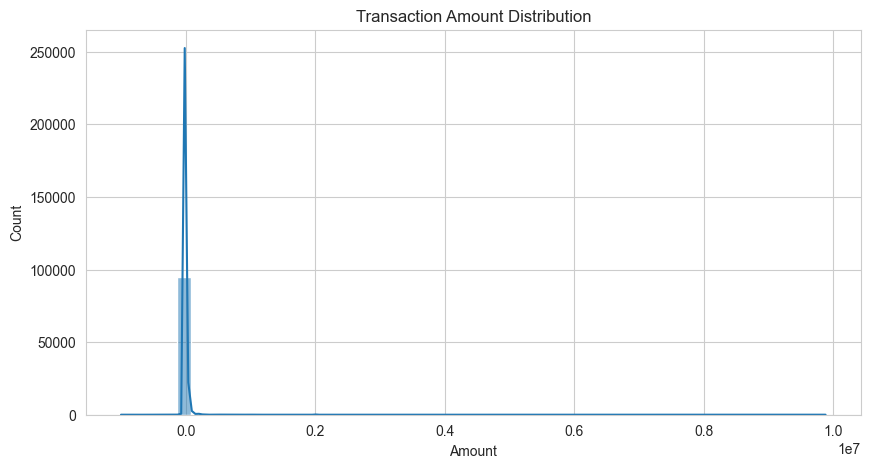

In [16]:
# Distribution of transaction amount

plt.figure(figsize=(10, 5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

### Numerical Feature Distribution Insights

- The `Amount` and `Value` features are highly right-skewed, indicating that most transactions involve small values while a few transactions are extremely large.
- The skewness suggests the possible presence of outliers and indicates that scaling or transformation techniques may be required during preprocessing.
- `CountryCode` contains only one unique value (256), suggesting that all transactions originate from the same country. This feature may provide limited predictive value.
- The `FraudResult` variable is highly imbalanced, with non-fraudulent transactions dominating the dataset. This indicates that evaluation metrics beyond accuracy will be important during model training.
- `PricingStrategy` appears concentrated around a few dominant categories, which may influence transaction behavior patterns.

In [17]:
# Correlation matrix for numerical features

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,CountryCode,Amount,Value,PricingStrategy,FraudResult
CountryCode,NaN,NaN,NaN,NaN,NaN
Amount,NaN,1.000000,0.989692,-0.061931,0.557370
Value,NaN,0.989692,1.000000,-0.017020,0.566739
PricingStrategy,NaN,-0.061931,-0.017020,1.000000,-0.033821
FraudResult,NaN,0.557370,0.566739,-0.033821,1.000000


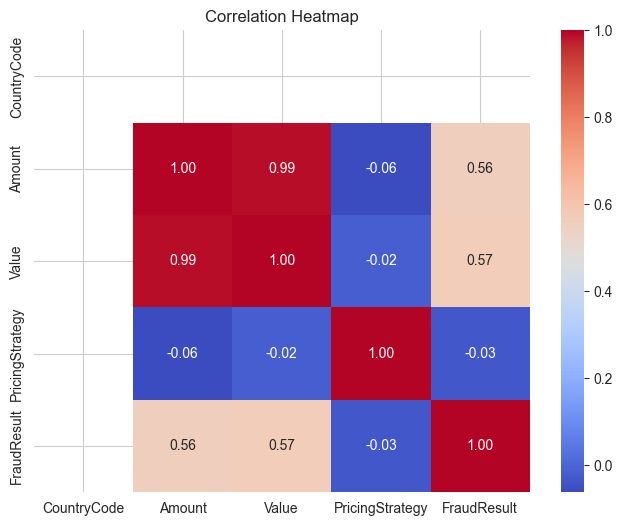

In [18]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis Insights

- `Amount` and `Value` show an extremely strong positive correlation (0.99), indicating that both variables contain nearly identical information. This suggests possible redundancy between the two features.
- `FraudResult` has a moderate positive correlation with both `Amount` and `Value`, implying that larger transactions may be more associated with fraudulent activity.
- `PricingStrategy` shows very weak correlation with other numerical variables, suggesting limited direct linear relationships.
- `CountryCode` produced NaN correlation values because it contains only one unique value across the dataset, indicating no variability.

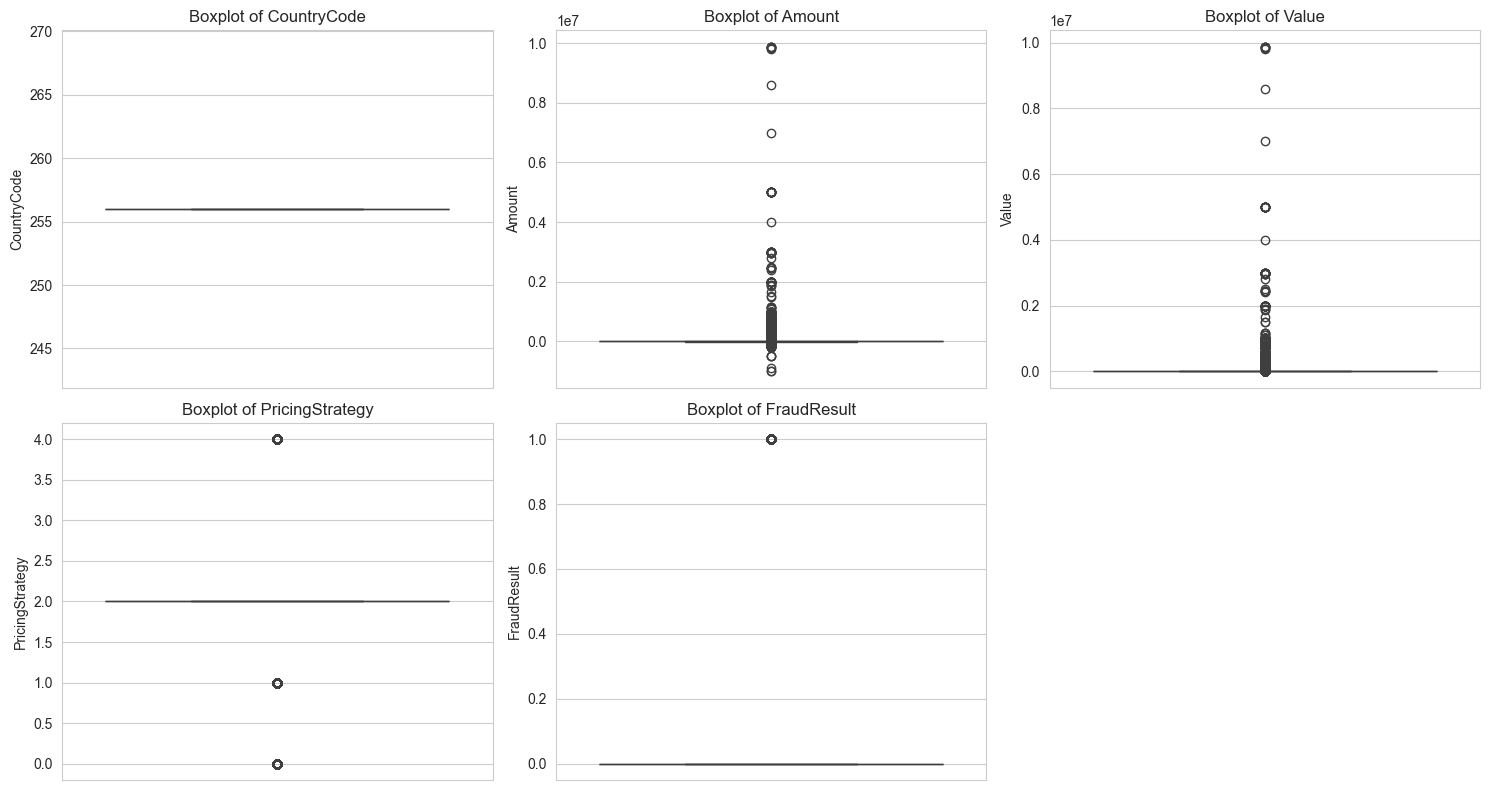

In [19]:
# Boxplots for numerical features

plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_columns, 1):
    
    plt.subplot(2, 3, i)
    
    sns.boxplot(y=df[column])
    
    plt.title(f"Boxplot of {column}")

plt.tight_layout()

plt.show()

## Outlier Detection Insights

- Significant outliers are present in both the `Amount` and `Value` features, confirming the strong right-skew observed in earlier distribution plots.
- Most transactions are concentrated near lower values, while a small number of transactions contain extremely large monetary amounts.
- These extreme values may represent high-value customer transactions, merchant payments, or potentially suspicious financial activities.
- The presence of strong outliers indicates that scaling, normalization, or transformation techniques may be necessary during preprocessing.
- `CountryCode` shows no meaningful variability because all transactions originate from the same country.
- `PricingStrategy` is concentrated around a dominant category, with a few less common strategy values appearing as isolated points.